In [6]:
from pathlib import Path
from scipy.io import loadmat
import scipy.signal as sgn
import pandas as pd
import numpy as np
import re
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score


In [7]:
from Functions import remove_baseline_filter,  preprocess_one_file , stem_to_subject_id , prepare_split_data_loaders,training_curve_plot , WindowDataset, CNN1D, train_model_with_loaders, eval_loader_binary , run_one_experiment , select_channels

## Preprocessing step

In [8]:

folder = Path(r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw")


# Parameters
FS_IN = 1000
FS_OUT = 60
WIN_LEN = 2048
STRIDE = WIN_LEN  # non-overlap
batch_size = 64

SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]

SCALE = {
    "ECG_mV": 1000.0,      # V -> mV
    "Fingerpulse": 10.0,
    "Cannula": 10.0,
    "Thermopod": 1.0
}

# ────────────────────────────────────────────────
# The baseline function 
SOS = remove_baseline_filter(FS_IN)

#────────────────────────────────────────────────
# Run over alla the files
mat_files = sorted(folder.glob("*.mat"))
participant_files = [f for f in mat_files if f.name.startswith("resting_state_participant_")]
print("Total .mat files:", len(mat_files))
print("Participant files:", len(participant_files))

#────────────────────────────────────────────────
# Split the files in mouth and nose 
nose_files, mouth_files, skipped = [], [], []
for f in participant_files:
    m = re.search(r"participant_(\d+)", f.stem)
    if not m:
        skipped.append(f.name)
        continue
    pid = int(m.group(1))
    if 10 <= pid <= 112:
        nose_files.append(f)
    elif 200 <= pid <= 312:
        mouth_files.append(f)
    else:
        skipped.append(f.name)

print("Nose files :", len(nose_files))
print("Mouth files:", len(mouth_files))
print("Skipped    :", len(skipped))

#────────────────────────────────────────────────
# Preprocess each group 
nose_tensors_by_participant = {}
mouth_tensors_by_participant = {}
failed = []
# 1. for nose 
for f in nose_files:
    try:
        nose_tensors_by_participant[f.stem] = preprocess_one_file(
            f,
            fs_in=FS_IN,
            fs_out=FS_OUT,
            win_len=WIN_LEN,
            stride=STRIDE,
            keep_signals=SIGNAL_ORDER,
            scale=SCALE,
            sos=SOS,
        )
    except Exception as e:
        failed.append((f.name, "nose", str(e)))
# 2. for mouth
for f in mouth_files:
    try:
        mouth_tensors_by_participant[f.stem] = preprocess_one_file(
            f,
            fs_in=FS_IN,
            fs_out=FS_OUT,
            win_len=WIN_LEN,
            stride=STRIDE,
            keep_signals=SIGNAL_ORDER,
            scale=SCALE,
            sos=SOS,
        )
    except Exception as e:
        failed.append((f.name, "mouth", str(e)))

print("Processed nose :", len(nose_tensors_by_participant))
print("Processed mouth:", len(mouth_tensors_by_participant))
print("Failed:", len(failed))

#────────────────────────────────────────────────
# Stacking the tensors 
if len(nose_tensors_by_participant) > 0:
    nose_keys = sorted(nose_tensors_by_participant.keys())
    X_nose = np.stack([nose_tensors_by_participant[k] for k in nose_keys], axis=0)
    print("X_nose shape:", X_nose.shape)  # (P_nose, n_windows, 2, 2048)

if len(mouth_tensors_by_participant) > 0:
    mouth_keys = sorted(mouth_tensors_by_participant.keys())
    X_mouth = np.stack([mouth_tensors_by_participant[k] for k in mouth_keys], axis=0)
    print("X_mouth shape:", X_mouth.shape)  # (P_mouth, n_windows, 2, 2048)


Total .mat files: 207
Participant files: 205
Nose files : 102
Mouth files: 103
Skipped    : 0
Processed nose : 102
Processed mouth: 103
Failed: 0
X_nose shape: (102, 9, 4, 2048)
X_mouth shape: (103, 9, 4, 2048)


In [9]:
# Checking that everything is working
mouth_keys = sorted(mouth_tensors_by_participant.keys()) 
# print(mouth_keys)
print("X_nose shape:", X_mouth .shape)
X_mouth = np.stack([mouth_tensors_by_participant[k] for k in mouth_keys], axis=0)
print("First 5 keys:", mouth_keys[:5])

X_nose shape: (103, 9, 4, 2048)
First 5 keys: ['resting_state_participant_201', 'resting_state_participant_210', 'resting_state_participant_211', 'resting_state_participant_212', 'resting_state_participant_213']


## Dataframe for the mouth 
The df was previously save cleaned and saved locally 

In [10]:
import pandas as pd
Path_subject = r"df_mouth.csv"
df_mouth= pd.read_csv(Path_subject)
df_mouth.head()

,Subject Number,Gender,Age
0,1,1,27
1,10,1,37
2,11,1,29
3,12,0,25
4,13,0,31


In [11]:
gender_by_subject = dict(zip(df_mouth["Subject Number"], df_mouth["Gender"]))
gender_by_subject # this is subject id and their correct gender 


{1: 1,
 10: 1,
 11: 1,
 12: 0,
 13: 0,
 14: 0,
 15: 0,
 16: 0,
 17: 0,
 18: 0,
 19: 0,
 20: 1,
 21: 0,
 22: 0,
 23: 0,
 24: 0,
 25: 0,
 26: 0,
 27: 0,
 28: 1,
 29: 1,
 30: 1,
 31: 0,
 32: 0,
 33: 0,
 34: 0,
 35: 0,
 36: 0,
 37: 1,
 38: 0,
 39: 1,
 40: 0,
 41: 0,
 42: 0,
 43: 0,
 44: 0,
 45: 0,
 46: 0,
 47: 0,
 48: 1,
 49: 0,
 50: 1,
 51: 0,
 52: 0,
 53: 1,
 54: 1,
 56: 0,
 57: 1,
 58: 0,
 59: 1,
 60: 0,
 61: 0,
 62: 0,
 63: 0,
 64: 1,
 65: 0,
 66: 0,
 67: 1,
 68: 1,
 69: 1,
 70: 1,
 71: 0,
 72: 0,
 73: 1,
 74: 0,
 75: 0,
 76: 0,
 77: 1,
 78: 0,
 79: 0,
 80: 0,
 81: 0,
 82: 0,
 83: 0,
 84: 0,
 85: 1,
 86: 1,
 87: 1,
 88: 0,
 89: 0,
 90: 0,
 91: 1,
 92: 0,
 93: 1,
 94: 0,
 95: 1,
 96: 0,
 97: 1,
 98: 1,
 99: 1,
 100: 1,
 101: 1,
 102: 0,
 103: 1,
 104: 0,
 105: 1,
 106: 0,
 107: 0,
 108: 1,
 109: 1,
 110: 0,
 111: 0,
 112: 1}

In [12]:
mouth_ids_from_files = np.array([stem_to_subject_id(k) for k in mouth_keys], dtype=int)

print("First 10 subject IDs from files:", mouth_ids_from_files[:10])
print("Number of participants from files:", len(mouth_ids_from_files))
print("Unique IDs:", len(np.unique(mouth_ids_from_files)))


mouth_ids_for_labels = mouth_ids_from_files - 200

print("First 10 raw mouth IDs:   ", mouth_ids_from_files[:10])
print("First 10 mapped label IDs:", mouth_ids_for_labels[:10])

y_mouth = np.array([gender_by_subject[sid] for sid in mouth_ids_for_labels], dtype=int)
print("y_nose gender:", y_mouth)
print("y_nose shape:", y_mouth.shape)
print("Gender counts [0,1]:", np.bincount(y_mouth))


First 10 subject IDs from files: [201 210 211 212 213 214 215 216 217 218]
Number of participants from files: 103
Unique IDs: 103
First 10 raw mouth IDs:    [201 210 211 212 213 214 215 216 217 218]
First 10 mapped label IDs: [ 1 10 11 12 13 14 15 16 17 18]
y_nose gender: [1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0
 0 0 1 0 1 0 0 1 1 0 1 0 1 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0
 0 1 1 1 0 0 0 1 0 1 0 1 0 1 1 1 1 1 0 1 0 1 0 0 1 1 0 0 1]
y_nose shape: (103,)
Gender counts [0,1]: [65 38]


# The split 

In [13]:


train_loader, val_loader, test_loader, meta = prepare_split_data_loaders(
    X_mouth, y_mouth,
    seed=6,
    batch_size=batch_size,
    normalize=True,
    return_meta=True
)

# baseline: majority-class accuracy on validation participants
X_val_p = meta["X_val_p"]
y_val_p = meta["y_val_p"]
baseline_acc = max(np.mean(y_val_p == 0), np.mean(y_val_p == 1))
# ────────────────────────────────────────────────
#  Quick sanity checks on test set 

print("\nFirst 20 test window labels:", meta['y_test'][10:40])

print("Example test window [0] – channel means:", meta['X_test'][0].mean(axis=1))

# If you want to see beginning of first channel of first test window:
print("Example test window[0] channel 0 – first 30 values:")
print(meta['X_test'][0, 0, :30])

X_mouth:     (103, 9, 4, 2048)
y_mouth:     (103,)   unique: [0 1]   counts: [65 38]

After normalization (train mean per ch): [-4.7959134e-09  6.7182587e-10 -1.6819527e-09  8.4376234e-10]
After normalization (train std  per ch): [1.         0.9999992  0.9999996  0.99999964]

Window-level shapes:
X_train:     (585, 4, 2048)  y_train: (585,)  counts: [369 216]
X_val  :     (153, 4, 2048)  y_val  : (153,)  counts: [99 54]
X_test :     (189, 4, 2048)  y_test : (189,)  counts: [117  72]

First 20 test window labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0]
Example test window [0] – channel means: [ 0.00054022 -0.00026018 -0.00040301  0.0008239 ]
Example test window[0] channel 0 – first 30 values:
[-1.0501543e-01 -4.5349255e-01 -4.2773762e-01 -8.5186404e-01
  2.0505893e+00  9.2298098e+00  4.9646468e+00 -5.9669185e-01
 -9.1158813e-01 -1.3486962e+00 -1.1989032e+00 -1.2329762e+00
 -1.0165839e+00 -9.0935355e-01 -8.4389001e-01 -8.6067557e-01
 -8.6207855e-01 -8.6781174e-01 -9

## Training step 

Epoch 01 | train loss 0.8836 acc 0.561 | val loss 0.8648 acc 0.353
Epoch 02 | train loss 0.8464 acc 0.615 | val loss 0.8500 acc 0.536
Epoch 03 | train loss 0.8337 acc 0.638 | val loss 0.8329 acc 0.575
Epoch 04 | train loss 0.8143 acc 0.667 | val loss 0.8199 acc 0.647
Epoch 05 | train loss 0.8235 acc 0.663 | val loss 0.8106 acc 0.686
Epoch 06 | train loss 0.8116 acc 0.665 | val loss 0.8048 acc 0.699
Epoch 07 | train loss 0.8178 acc 0.644 | val loss 0.7982 acc 0.725
Epoch 08 | train loss 0.8071 acc 0.674 | val loss 0.7972 acc 0.719
Epoch 09 | train loss 0.7957 acc 0.697 | val loss 0.8009 acc 0.680
Epoch 10 | train loss 0.7902 acc 0.670 | val loss 0.7984 acc 0.680
Epoch 11 | train loss 0.7733 acc 0.696 | val loss 0.7963 acc 0.693
Epoch 12 | train loss 0.7735 acc 0.701 | val loss 0.7999 acc 0.667
Epoch 13 | train loss 0.7603 acc 0.703 | val loss 0.7922 acc 0.654
Epoch 14 | train loss 0.7622 acc 0.718 | val loss 0.7927 acc 0.654
Epoch 15 | train loss 0.7390 acc 0.754 | val loss 0.7963 acc 0

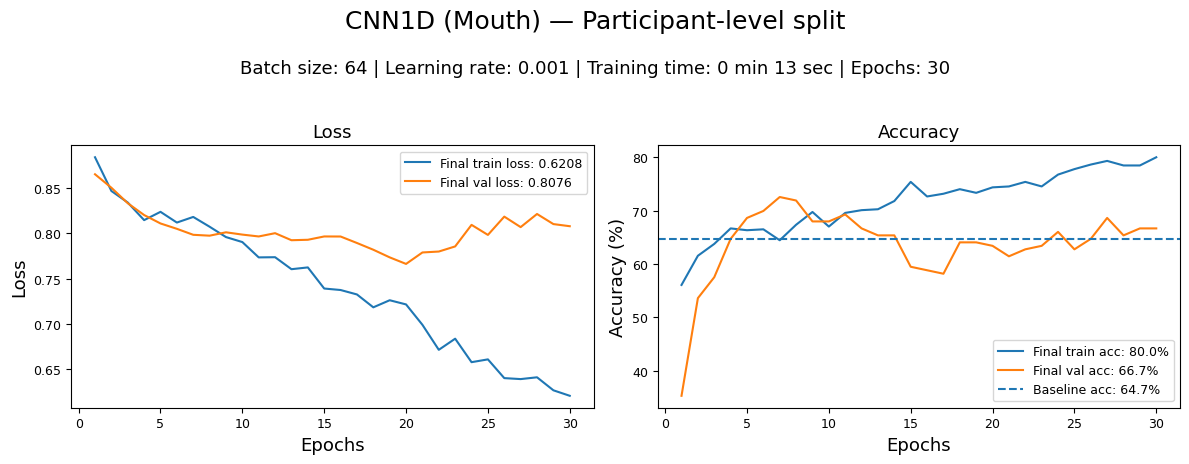

In [14]:
Epochs = 50 
lr = 1e-3
patience=10 

model = CNN1D(len(SIGNAL_ORDER))


t0 = time.time()
model, trL, vaL, trA, vaA, trP, valP, _= train_model_with_loaders(
    model,
    train_loader,
    val_loader,
    epochs=Epochs,
    lr=lr,
    patience=patience,
    use_pos_weight=True
)
t1 = time.time()


print("Final train acc:", trA[-1])
print("Final val acc:", vaA[-1])

training_curve_plot(
    title="CNN1D (Mouth) — Participant-level split",
    train_losses=trL,
    val_losses=vaL,
    train_accs=trA,
    val_accs=vaA,
    batch_size=64,
    learning_rate=0.001,
    training_time=(t1 - t0),
    baseline_acc=baseline_acc
)

## The evalutaion section

In [15]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score

def eval_loader_binary(model, loader, device=None, threshold=0.5, verbose=True, name="LOADER"):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)
    model.eval()

    y_prob_list, y_true_list, y_pred_list = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)

            logits = model(xb).view(-1)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            preds = (probs >= threshold).astype(int)

            y_prob_list.append(probs)
            y_pred_list.append(preds)
            y_true_list.append(yb.detach().cpu().numpy().astype(int).reshape(-1))

    y_true = np.concatenate(y_true_list) if y_true_list else np.array([], dtype=int)
    y_pred = np.concatenate(y_pred_list) if y_pred_list else np.array([], dtype=int)
    y_prob = np.concatenate(y_prob_list) if y_prob_list else np.array([], dtype=float)

    acc = accuracy_score(y_true, y_pred) if len(y_true) else float("nan")

    if verbose:
        print(f"{name} accuracy (window-level): {acc:.4f}")

    return y_true, y_pred, y_prob, acc


In [16]:
print(eval_loader_binary)


<function eval_loader_binary at 0x00000282CC84E680>


In [17]:
y_tr, yhat_tr, p_tr, acc_tr = eval_loader_binary(model, train_loader, name="TRAIN")
y_va, yhat_va, p_va, acc_va = eval_loader_binary(model, val_loader,   name="VAL")
y_te, yhat_te, p_te, acc_te = eval_loader_binary(model, test_loader,  name="TEST")


TRAIN accuracy (window-level): 0.7726
VAL accuracy (window-level): 0.6340
TEST accuracy (window-level): 0.7513


In [18]:
# for the test


print(f"Accuracy:           {accuracy_score(y_te, yhat_te):.4f}")
print(f"Balanced acc:       {balanced_accuracy_score(y_te, yhat_te):.4f}")
print(f"F1 (positive):      {f1_score(y_te, yhat_te):.4f}")
print(f"ROC AUC:            {roc_auc_score(y_te, p_te):.4f}")
print(f"Average Precision:  {average_precision_score(y_te, p_te):.4f}")

print("\nCM:\n", confusion_matrix(y_te, yhat_te))
print(classification_report(y_te, yhat_te, digits=4))


Accuracy:           0.7513
Balanced acc:       0.7457
F1 (positive):      0.6887
ROC AUC:            0.7822
Average Precision:  0.7836

CM:
 [[90 27]
 [20 52]]
              precision    recall  f1-score   support

           0     0.8182    0.7692    0.7930       117
           1     0.6582    0.7222    0.6887        72

    accuracy                         0.7513       189
   macro avg     0.7382    0.7457    0.7408       189
weighted avg     0.7572    0.7513    0.7533       189



In [19]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Put your data in a list of tuples
datasets = [
    ("TRAIN", y_tr,  yhat_tr,  p_tr),
    ("VAL",   y_va,  yhat_va,  p_va),
    ("TEST",  y_te,  yhat_te,  p_te),
]

for name, y_true, y_pred, y_prob in datasets:
    print(f"\n ----- {name}----")
    
    acc     = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred)
    auc     = roc_auc_score(y_true, y_prob)
    ap      = average_precision_score(y_true, y_prob)
    
    print(f"Accuracy:              {acc:.4f}")
    print(f"Balanced accuracy:     {bal_acc:.4f}")
    print(f"F1 (positive class):   {f1:.4f}")
    print(f"ROC AUC:               {auc:.4f}")
    print(f"Average Precision:     {ap:.4f}")
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    
    print("━" * 50)


 ----- TRAIN----
Accuracy:              0.7726
Balanced accuracy:     0.7459
F1 (positive class):   0.6764
ROC AUC:               0.8416
Average Precision:     0.7309

Confusion Matrix:
[[313  56]
 [ 77 139]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8026    0.8482    0.8248       369
           1     0.7128    0.6435    0.6764       216

    accuracy                         0.7726       585
   macro avg     0.7577    0.7459    0.7506       585
weighted avg     0.7694    0.7726    0.7700       585

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 ----- VAL----
Accuracy:              0.6340
Balanced accuracy:     0.6035
F1 (positive class):   0.4909
ROC AUC:               0.7447
Average Precision:     0.5954

Confusion Matrix:
[[70 29]
 [27 27]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7216    0.7071    0.7143        99
           1     0.4821    0.5000    0.4909        

In [20]:


# print(f"Accuracy:           {accuracy_score(y_true, y_pred):.4f}")
# print(f"Balanced acc:       {balanced_accuracy_score(y_true, y_pred):.4f}")
# print(f"F1 (positive):      {f1_score(y_true, y_pred):.4f}")
# print(f"ROC AUC:            {roc_auc_score(y_true, y_prop):.4f}")
# print(f"Average Precision:  {average_precision_score(y_true, y_prop):.4f}")
# print("\nCM:\n", confusion_matrix(y_true, y_pred))
# print(classification_report(y_true, y_pred, digits=4))

In [21]:


FULL_SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]

signal_sets = [
    ["ECG_mV"],
    ["Fingerpulse"],
    ["Cannula"],                          # 1 signal
    ["Thermopod"],                        # 1 signal
    #["Cannula", "Thermopod"],             # 2 signals
    ["ECG_mV", "Fingerpulse"],            # 2 signals
    ["ECG_mV", "Cannula"],            # 2 signals
    ["ECG_mV", "Thermopod"],            # 2 signals
    ["ECG_mV", "Fingerpulse","Thermopod"],   # 3 signals
    ["ECG_mV", "Fingerpulse", "Cannula"],   # 3 signals
    FULL_SIGNAL_ORDER,                    # 4 signals
]

seeds = [1, 2, 3, 4, 5]


In [22]:
results = []
for keep in signal_sets:
    for seed in seeds:
        m = run_one_experiment(
            X_full=X_mouth,
            y=y_mouth,
            full_order=FULL_SIGNAL_ORDER,
            keep_signals=keep,
            seed=seed,
            Epochs=50,
            lr=1e-3,
            patience=10,
            batch_size=64,
        )
        print(f"done: seed={seed}, signals={keep} -> acc={m['test_acc']:.3f}, auc={m['test_roc_auc']:.3f}")
        results.append(m)


Epoch 01 | train loss 0.8713 acc 0.508 | val loss 0.8719 acc 0.353
Epoch 02 | train loss 0.8632 acc 0.538 | val loss 0.8666 acc 0.523
Epoch 03 | train loss 0.8353 acc 0.621 | val loss 0.8558 acc 0.569
Epoch 04 | train loss 0.8424 acc 0.588 | val loss 0.8362 acc 0.497
Epoch 05 | train loss 0.8308 acc 0.621 | val loss 0.8354 acc 0.641
Epoch 06 | train loss 0.8219 acc 0.626 | val loss 0.8346 acc 0.673
Epoch 07 | train loss 0.8093 acc 0.655 | val loss 0.8456 acc 0.614
Epoch 08 | train loss 0.8158 acc 0.646 | val loss 0.8624 acc 0.647
Epoch 09 | train loss 0.7985 acc 0.662 | val loss 0.8726 acc 0.575
Epoch 10 | train loss 0.7862 acc 0.651 | val loss 0.8567 acc 0.536
Epoch 11 | train loss 0.7867 acc 0.641 | val loss 0.8703 acc 0.575
Epoch 12 | train loss 0.7724 acc 0.670 | val loss 0.8844 acc 0.575
Epoch 13 | train loss 0.7653 acc 0.665 | val loss 0.9175 acc 0.569
Epoch 14 | train loss 0.7704 acc 0.667 | val loss 0.9350 acc 0.542
Epoch 15 | train loss 0.7391 acc 0.675 | val loss 0.9402 acc 0

In [23]:
df = pd.DataFrame(results)
df.to_csv("df_mouth_different_Signals.csv", index=False)
print(df.shape)
df.head(50)


(50, 10)


,seed,keep_signals,n_signals,test_acc,test_bal_acc,test_f1,test_roc_auc,test_avg_precision,final_train_acc,final_val_acc
0,1,"(ECG_mV,)",1,0.587302,0.541132,0.390625,0.592236,0.398589,0.688889,0.555556
1,2,"(ECG_mV,)",1,0.666667,0.594551,0.400000,0.686610,0.617493,0.709402,0.705882
2,3,"(ECG_mV,)",1,0.597884,0.579060,0.486486,0.585589,0.396321,0.690598,0.751634
3,4,"(ECG_mV,)",1,0.433862,0.398504,0.251748,0.430674,0.319463,0.769231,0.614379
4,5,"(ECG_mV,)",1,0.449735,0.448718,0.380952,0.462844,0.391910,0.711111,0.594771
5,1,"(Fingerpulse,)",1,0.587302,0.535791,0.370968,0.691477,0.521235,0.661538,0.575163
6,2,"(Fingerpulse,)",1,0.544974,0.632479,0.626087,0.791192,0.638806,0.644444,0.640523
7,3,"(Fingerpulse,)",1,0.513228,0.521368,0.465116,0.605294,0.476601,0.666667,0.633987
8,4,"(Fingerpulse,)",1,0.629630,0.636752,0.578313,0.722222,0.563750,0.634188,0.568627
9,5,"(Fingerpulse,)",1,0.380952,0.500000,0.551724,0.641738,0.521459,0.670085,0.549020


In [26]:
import numpy as np

summary = df.groupby("keep_signals")["test_roc_auc"].agg(
    median=np.median,
    p25=lambda x: np.percentile(x, 25),
    p75=lambda x: np.percentile(x, 75),
).reset_index()

summary


,keep_signals,median,p25,p75
0,"(Cannula,)",0.717236,0.678419,0.735043
1,"(ECG_mV,)",0.585589,0.462844,0.592236
2,"(ECG_mV, Cannula)",0.605294,0.603276,0.697768
3,"(ECG_mV, Fingerpulse)",0.639601,0.609212,0.694444
4,"(ECG_mV, Fingerpulse, Cannula)",0.764957,0.696700,0.816833
5,"(ECG_mV, Fingerpulse, Cannula, Thermopod)",0.729345,0.700261,0.762821
6,"(ECG_mV, Fingerpulse, Thermopod)",0.662037,0.588200,0.692070
7,"(ECG_mV, Thermopod)",0.521486,0.461657,0.556624
8,"(Fingerpulse,)",0.691477,0.641738,0.722222
9,"(Thermopod,)",0.566358,0.530389,0.590693


<Figure size 1400x600 with 0 Axes>

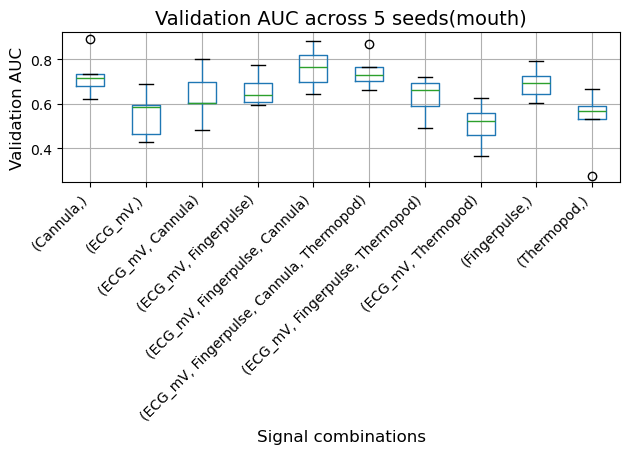

In [35]:
import matplotlib.pyplot as plt



plt.figure(figsize=(14,6))  
df.boxplot(column="test_roc_auc", by="keep_signals")
plt.title("Validation AUC across 5 seeds(mouth)", fontsize=14)
plt.suptitle("")
plt.ylabel("Validation AUC", fontsize=12)
plt.xlabel("Signal combinations", fontsize=12)

plt.xticks(rotation=45, ha="right")   # better label alignment
plt.tight_layout()
plt.show()
